# LocoSense — Phase 1: Setup & EDA

**Before RUnning:** Make sure VS Code shows `./venv` as the kernel (top-right of this notebook).  
If not → click the kernel selector → *Python Environments* → `venv`.

| | |
|---|---|
| Dataset | `data/raw/locosense_dataset.numbers` |
| Rows | 6,925 |
| Columns | 22 |
| Locos | 50 unique |
| Goal | Load, verify, explore — output `data/processed/locosense_phase1.csv` |

In [2]:
import os
from pathlib import Path
print("RAW cwd:", os.getcwd())
print("RAW resolve:", Path().resolve())
print("RAW parent:", Path().resolve().parent)

RAW cwd: /Users/anshulrathore/Desktop/intern/locosense/notebooks
RAW resolve: /Users/anshulrathore/Desktop/intern/locosense/notebooks
RAW parent: /Users/anshulrathore/Desktop/intern/locosense


---
## Cell 1 — Imports & path setup

In [3]:
import sys
from pathlib import Path

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

#  Paths
NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR
RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR   = ROOT / 'reports' / 'figures'

CSV_RAW    = RAW_DIR / 'locosense dataset.csv'
CSV_PHASE1    = PROCESSED_DIR / 'locosense phase1.csv'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Sanity check 
assert CSV_RAW.exists(), (
    f"Dataset not found at {CSV_RAW}\n"
    "Make sure locosense dataset.csv is inside data/raw/"
)

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Root    : {ROOT}')
print('All imports ok')

Python  : 3.11.3
pandas  : 3.0.3
numpy   : 2.4.6
Root    : /Users/anshulrathore/Desktop/intern/locosense/notebooks
All imports ok


---
## 2. Load `.numbers` file -> export CSV

In [4]:
df_raw = pd.read_csv(RAW_DIR / "locosense dataset.csv")

In [5]:

# Quick check
print(f'Loaded  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Columns : {list(df_raw.columns)}')
df_raw.head(3)

Loaded  : 6,925 rows × 22 columns
Columns : ['loco id', 'loco type', 'zone', 'manufacture year', 'cycle', 'totalcycles', 'days since service', 'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)', 'RU', 'failure label', 'risk category']


,loco id,loco type,zone,manufacture year,cycle,totalcycles,days since service,engine temp (C),oil pressure (bar),vibration (mms),...,bearing temp (C),RPM,exhaust temp (C),turbo pressure (bar),load factor (%),battery voltage (V),brake pressure (bar),RU,failure label,risk category
0,WDG4-1001,WDG4,NR,2014,1,174,-12,78.563,3.379,1.993,...,59.894,917.562,323.872,2.033,76.166,24.098,4.137,173,0,Low
1,WDG4-1001,WDG4,NR,2014,2,174,-10,83.015,3.785,2.354,...,59.337,913.649,325.032,1.775,70.422,23.585,3.951,172,0,Low
2,WDG4-1001,WDG4,NR,2014,3,174,-8,81.256,3.553,1.808,...,63.438,881.074,318.182,1.891,64.320,24.109,4.280,171,0,Low


---
## Cell 3 — Rename columns to snake case

In [6]:
# COLUMN_MAP = {
#     'loco id'              : 'loco_id',
#     'loco type'            : 'loco_type',
#     'zone'                 : 'zone',
#     'manufacture year'     : 'manufacture_year',
#     'cycle'                : 'cycle',
#     'totalcycles'          : 'total_cycles',
#     'days since service'   : 'days_since_service',
#     'engine temp   (C)'    : 'engine_temp',
#     'oil pressure (bar)'   : 'oil_pressure',
#     'vibration    (mms)'   : 'vibration',
#     'fuel efficiency (%)'  : 'fuel_efficiency',
#     'coolant temp (C)'     : 'coolant_temp',
#     'bearing temp  (C)'    : 'bearing_temp',
#     'RPM'                  : 'rpm',
#     'exhaust temp (C)'     : 'exhaust_temp',
#     'turbo pressure (bar)' : 'turbo_pressure',
#     'load factor (%)'      : 'load_factor',
#     'battery voltage (V)'  : 'battery_voltage',
#     'brake pressure (bar)' : 'brake_pressure',
#     'RU'                   : 'RU',
#     'failure label'        : 'failure_label',
#     'risk category'        : 'risk_category',
# }

# df_raw = df_raw_raw.rename(columns=COLUMN_MAP).copy()

# Column groups — used throughout all phases
SENSOR_COLS = [
    'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)',
    'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)',
    'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)',
]
META_COLS  = ['loco id', 'loco type', 'zone', 'manufacture year', 'cycle', 'total cycles']
LABEL_COLS = ['RU', 'failure label', 'risk category', 'days since service']

print('Columns after rename:')
for col in df_raw.columns:
    print(f'  {col:<25} {df_raw[col].dtype}')

Columns after rename:
  loco id                   str
  loco type                 str
  zone                      str
  manufacture year          int64
  cycle                     int64
  totalcycles               int64
  days since service        int64
  engine temp   (C)         float64
  oil pressure (bar)        float64
  vibration    (mms)        float64
  fuel efficiency (%)       float64
  coolant temp (C)          float64
  bearing temp  (C)         float64
  RPM                       float64
  exhaust temp (C)          float64
  turbo pressure (bar)      float64
  load factor (%)           float64
  battery voltage (V)       float64
  brake pressure (bar)      float64
  RU                        int64
  failure label             int64
  risk category             str


---
## Cell 4 — Data quality checks

In [7]:
nulls = df_raw.isnull().sum()
if nulls.sum() == 0:
    print('No nulls')
else:
    print(nulls[nulls > 0])

print()
dupes = df_raw.duplicated().sum()
print(f'{dupes} duplicate rows' if dupes else 'No duplicate rows ')

print()
id_cycle_dupes = df_raw.duplicated(subset=['loco id', 'cycle']).sum()
print(f'{id_cycle_dupes} duplicates' if id_cycle_dupes else 'All pairs unique')

print()
neg = df_raw[df_raw['days since service'] < 0]
print(f'{len(neg)} rows with negative values')
print(f'Range: {df_raw["days since service"].min():.0f}  to  {df_raw["days since service"].max():.0f}')

print()
print(f'{int(df_raw["manufacture year"].min())}  to  {int(df_raw["manufacture year"].max())} ')

No nulls

No duplicate rows 

All pairs unique

441 rows with negative values
Range: -38  to  180

2010  to  2020 


---
## Cell 5 — Fleet overview

Unique locomotives : 50
Loco types         : ['WAG9', 'WAP5', 'WAP7', 'WDG4', 'WDP4B']
Railway zones      : ['CR', 'ER', 'NR', 'SR', 'WR']



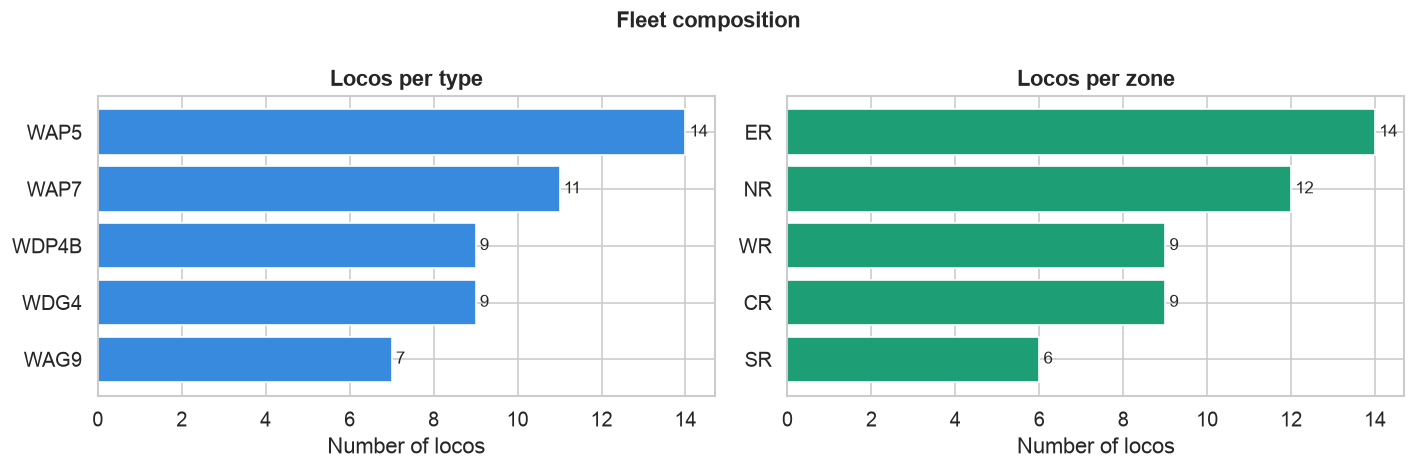

Saved reports/figures/fleet overview.png


In [8]:
print(f'Unique locomotives : {df_raw["loco id"].nunique()}')
print(f'Loco types         : {sorted(df_raw["loco type"].unique())}')
print(f'Railway zones      : {sorted(df_raw["zone"].unique())}')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Locos per type
type_counts = df_raw.groupby('loco type')['loco id'].nunique().sort_values(ascending=True)
axes[0].barh(type_counts.index, type_counts.values, color='#378ADD')
axes[0].set_title('Locos per type', fontweight='bold')
axes[0].set_xlabel('Number of locos')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# Locos per zone
zone_counts = df_raw.groupby('zone')['loco id'].nunique().sort_values(ascending=True)
axes[1].barh(zone_counts.index, zone_counts.values, color='#1D9E75')
axes[1].set_title('Locos per zone', fontweight='bold')
axes[1].set_xlabel('Number of locos')
for i, v in enumerate(zone_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.suptitle('Fleet composition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fleet overview.png')
plt.show()
print('Saved reports/figures/fleet overview.png')

---
## Cell 6 — Label distributions

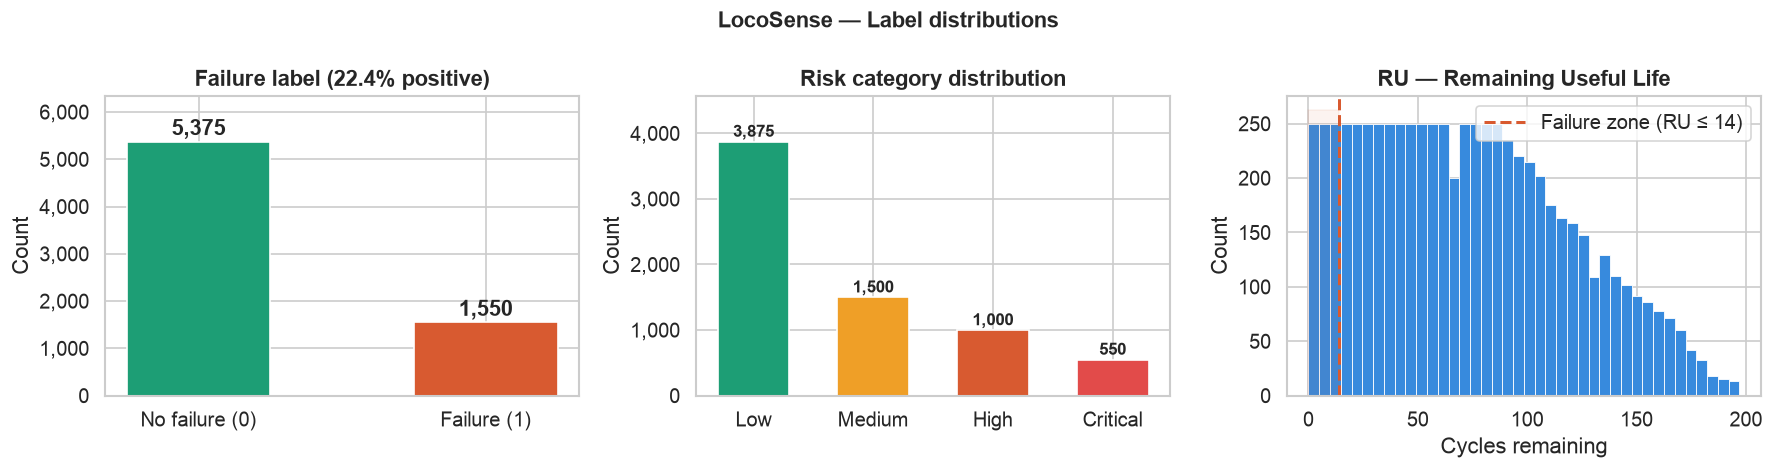

Saved reports/figures/label distributions.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Failure label ─────────────────────────────────────────────────────────────
ax = axes[0]
counts = df_raw['failure label'].value_counts().sort_index()
bars = ax.bar(['No failure (0)', 'Failure (1)'],
              counts.values, color=['#1D9E75', '#D85A30'], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
failure_pct = counts.get(1.0, 0) / counts.sum() * 100
ax.set_title(f'Failure label ({failure_pct:.1f}% positive)', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Risk category ─────────────────────────────────────────────────────────────
ax = axes[1]
risk_order  = ['Low', 'Medium', 'High', 'Critical']
risk_colors = ['#1D9E75', '#EF9F27', '#D85A30', '#E24B4A']
risk_counts = df_raw['risk category'].value_counts().reindex(risk_order)
bars = ax.bar(risk_order, risk_counts.values, color=risk_colors, width=0.6)
for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Risk category distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, risk_counts.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── RU histogram ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.hist(df_raw['RU'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
ax.axvline(14, color='#D85A30', linestyle='--', linewidth=1.8,
           label='Failure zone (RU ≤ 14)')
ax.fill_between([0, 14], 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 600,
                color='#D85A30', alpha=0.07)
ax.set_title('RU — Remaining Useful Life', fontweight='bold')
ax.set_xlabel('Cycles remaining')
ax.set_ylabel('Count')
ax.legend()

plt.suptitle('LocoSense — Label distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'label distributions.png')
plt.show()
print('Saved reports/figures/label distributions.png')

---
## Cell 7 — Risk category × failure label cross-tab

In [10]:
cross = pd.crosstab(
    df_raw['risk category'], df_raw['failure label'],
    margins=True
)
cross.columns = ['No failure (0)', 'Failure (1)', 'Total']
cross['Failure rate %'] = (cross['Failure (1)'] / cross['Total'] * 100).round(1)

# Reorder rows
order = ['Low', 'Medium', 'High', 'Critical', 'All']
cross = cross.reindex([o for o in order if o in cross.index])

print('Risk category × Failure label')
print(cross.to_string())
print()
print('Key insight: Critical category should have 100% failure rate — verify alignment.')

Risk category × Failure label
               No failure (0)  Failure (1)  Total  Failure rate %
risk category                                                    
Low                      3875            0   3875             0.0
Medium                   1500            0   1500             0.0
High                        0         1000   1000           100.0
Critical                    0          550    550           100.0
All                      5375         1550   6925            22.4

Key insight: Critical category should have 100% failure rate — verify alignment.


---
## Cell 8 — Sensor statistics

In [11]:
print(df_raw.columns.tolist())
print(SENSOR_COLS)

['loco id', 'loco type', 'zone', 'manufacture year', 'cycle', 'totalcycles', 'days since service', 'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)', 'RU', 'failure label', 'risk category']
['engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)']


In [12]:
print('Sensor summary statistics')
print(df_raw[SENSOR_COLS].describe().round(3).to_string())

Sensor summary statistics
       engine temp   (C)  oil pressure (bar)  vibration    (mms)  fuel efficiency (%)  coolant temp (C)  bearing temp  (C)       RPM  exhaust temp (C)  turbo pressure (bar)  load factor (%)  battery voltage (V)  brake pressure (bar)
count           6925.000            6925.000            6925.000             6925.000          6925.000           6925.000  6925.000          6925.000              6925.000         6925.000             6925.000              6925.000
mean              89.295               3.074               2.887               90.997            79.934             64.568   881.364           335.083                 1.588           72.112               23.391                 3.896
std               11.316               0.601               1.656                4.695             7.748              7.515    34.648            24.387                 0.300            4.947                0.995                 0.461
min               73.677               0.6

---
## Cell 9 — Sensor distributions: no-failure vs failure

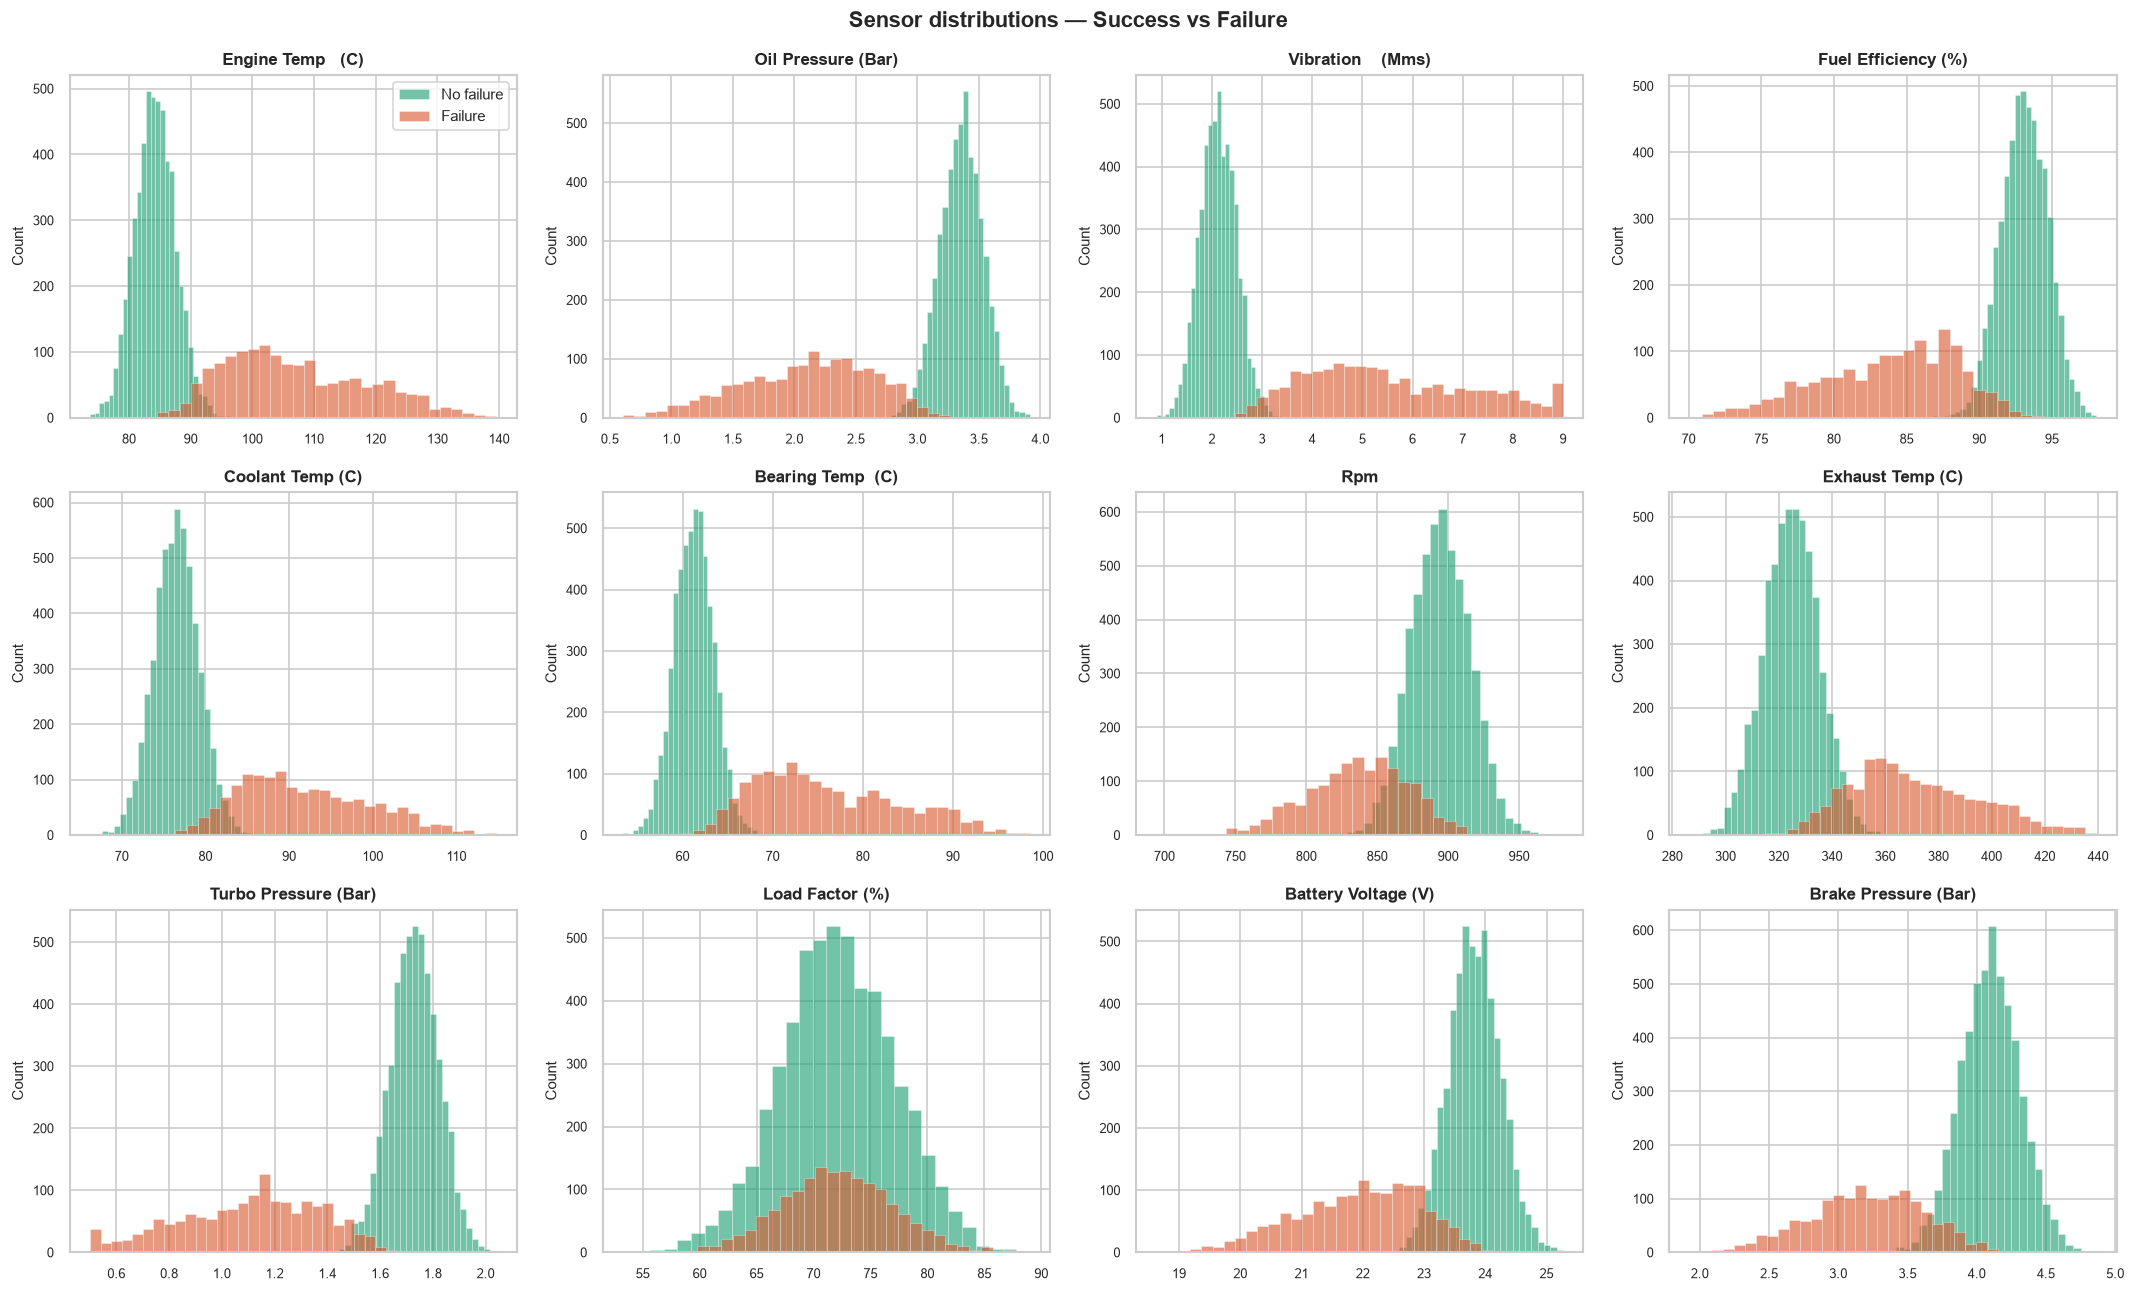

Saved reports/figures/sensor distributions.png


In [13]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

palette = {0.0: '#1D9E75', 1.0: '#D85A30'}
label_map = {0.0: 'No failure', 1.0: 'Failure'}

for i, col in enumerate(SENSOR_COLS):
    ax = axes[i]
    for lval, color in palette.items():
        subset = df_raw[df_raw['failure label'] == lval][col]
        ax.hist(subset, bins=30, alpha=0.62, color=color,
                label=label_map[lval], edgecolor='white', linewidth=0.3)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Sensor distributions — Success vs Failure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensor distributions.png')
plt.show()
print('Saved reports/figures/sensor distributions.png')

---
## Cell 10 — Correlation heatmap

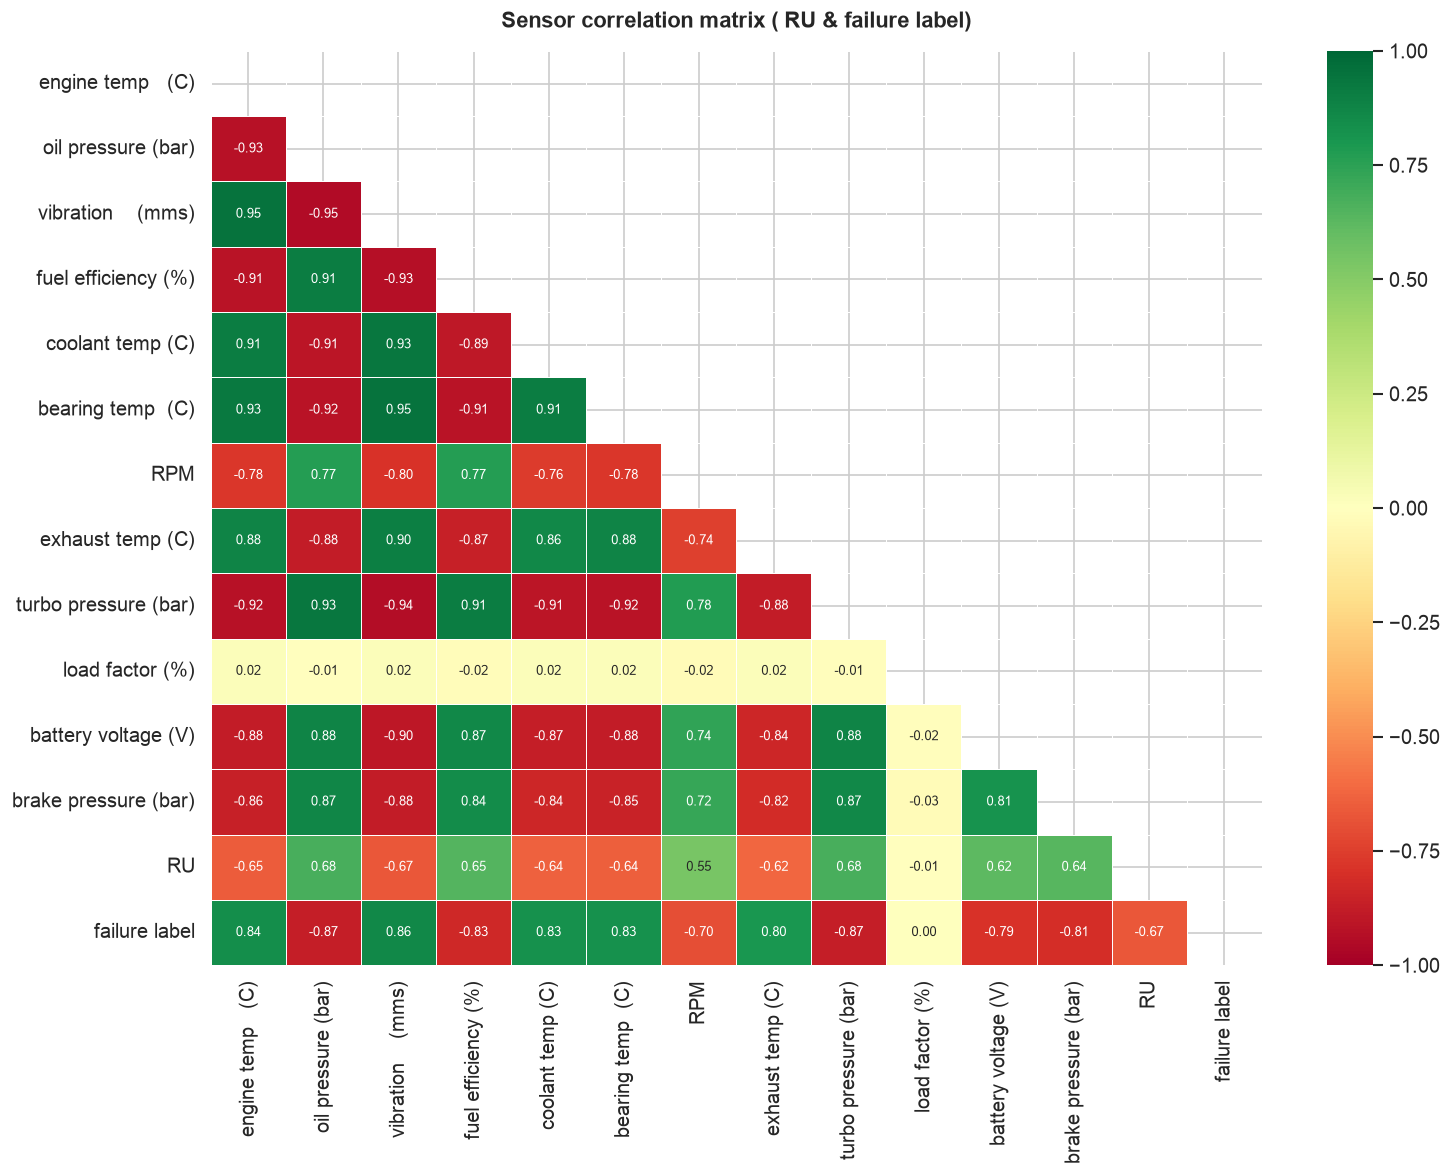

In [14]:
fig, ax = plt.subplots(figsize=(13, 10))

corr_cols = SENSOR_COLS + ['RU', 'failure label']
corr = df_raw[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Sensor correlation matrix ( RU & failure label)',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation heatmap.png')
plt.show()
# print('Saved reports/figures/correlation heatmap.png')

---
## Cell 11 — RU trend for 6 sample locomotives

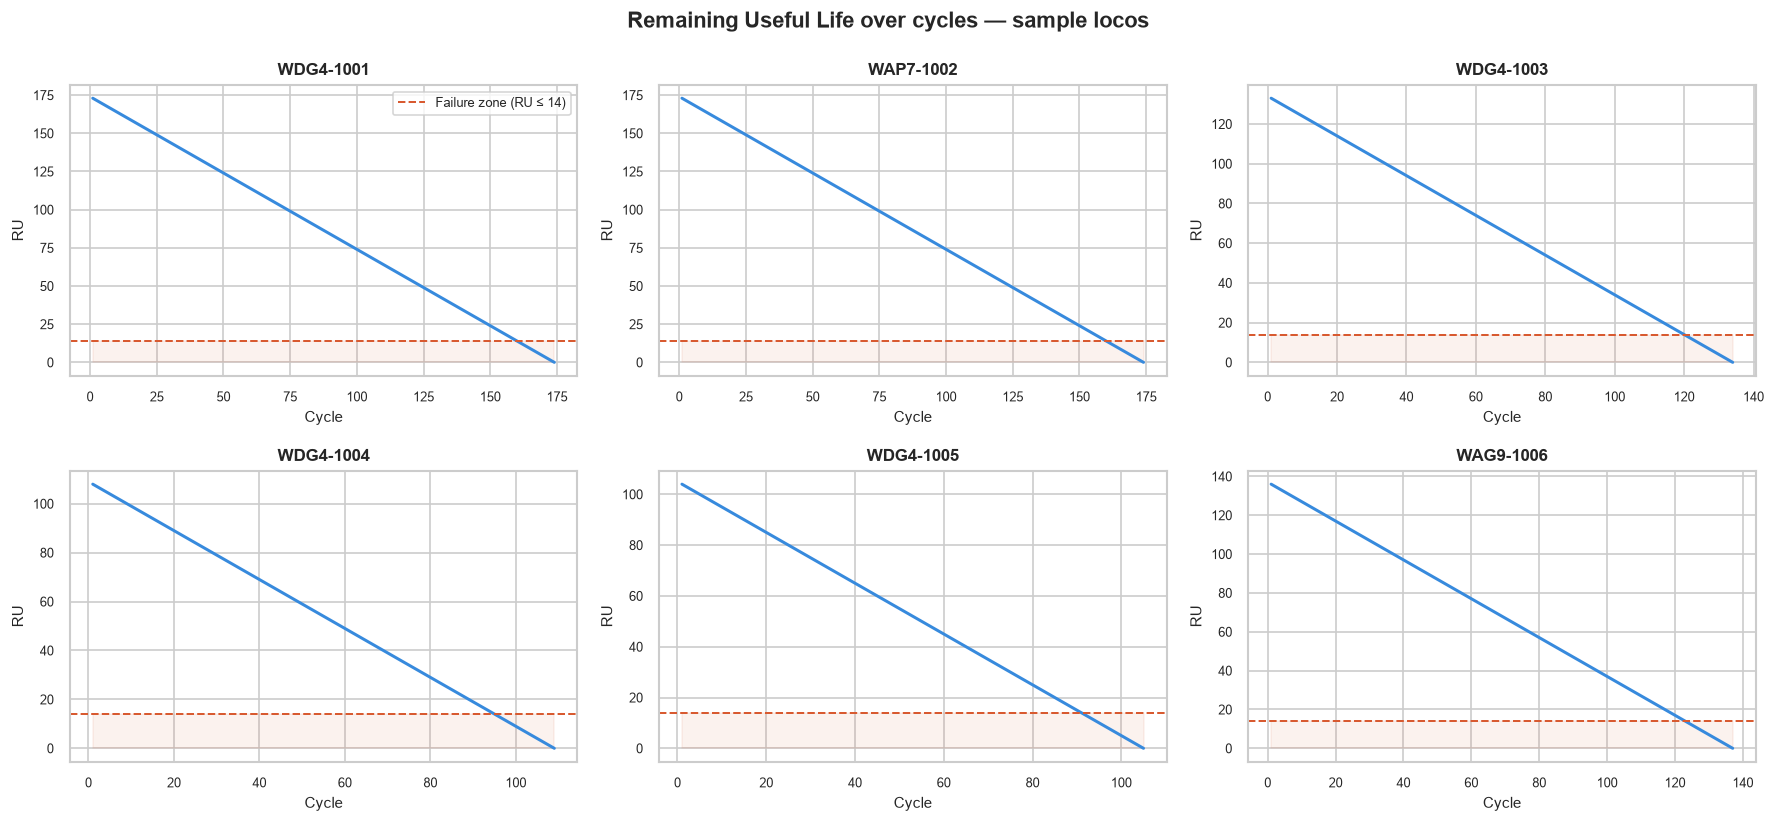

In [15]:
sample_locos = df_raw['loco id'].unique()[:6]
fig, axes    = plt.subplots(2, 3, figsize=(15, 7))
axes         = axes.flatten()

for i, loco in enumerate(sample_locos):
    ax      = axes[i]
    loco_df_raw = df_raw[df_raw['loco id'] == loco].sort_values('cycle')

    ax.plot(loco_df_raw['cycle'], loco_df_raw['RU'],
            color='#378ADD', linewidth=1.8)
    ax.axhline(14, color='#D85A30', linestyle='--', linewidth=1.2,
               label='Failure zone (RU ≤ 14)')
    ax.fill_between(loco_df_raw['cycle'], 0, 14, color='#D85A30', alpha=0.08)

    ax.set_title(loco, fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle', fontsize=9)
    ax.set_ylabel('RU', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Remaining Useful Life over cycles — sample locos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'RU trends.png')
plt.show()
# print('Saved → reports/figures/RU_trends.png')

---
## Cell 12 — Save processed file & Phase 1 summary

In [16]:
# Save with clean column names for Phase 2
df_raw.to_csv(CSV_PHASE1, index=False)

n_neg = (df_raw['days since service'] < 0).sum()
spw   = round((df_raw['failure label'] == 0).sum() / (df_raw['failure label'] == 1).sum(), 2)

print('  PHASE 1 COMPLETE')
print(f'  Rows : {len(df_raw):,}')
print(f'  Columns : {df_raw.shape[1]}')
print(f'  Unique locos: {df_raw["loco id"].nunique()}')
print(f'  Loco types : {sorted(df_raw["loco type"].unique())}')
print(f'  Railway zones : {sorted(df_raw["zone"].unique())}')
print(f'  Nulls: {df_raw.isnull().sum().sum()}')
print(f'  Failure rate : {df_raw["failure label"].mean()*100:.1f}%')
print(f'  scale pos weight : {spw}  use this in XGBoost Phase 3')
print(f'  RU range : {int(df_raw["RU"].min())} – {int(df_raw["RU"].max())} cycles')
print(f'  Risk categories : {sorted(df_raw["risk category"].unique())}')
print()
# print('  FLAGS FOR PHASE 2')
# print(f'  [!] {n_neg} rows with negative days_since_service')
# print( '      Decision: clip at 0 OR treat as pre-service window feature')
# print( '  [!] 4 risk categories — decide binary vs 4-class in Phase 3')
# print( '  [i] RU + failure_label already computed — skip label engineering')
# print( '  [i] No nulls — no imputation step needed')

  PHASE 1 COMPLETE
  Rows : 6,925
  Columns : 22
  Unique locos: 50
  Loco types : ['WAG9', 'WAP5', 'WAP7', 'WDG4', 'WDP4B']
  Railway zones : ['CR', 'ER', 'NR', 'SR', 'WR']
  Nulls: 0
  Failure rate : 22.4%
  scale pos weight : 3.47  use this in XGBoost Phase 3
  RU range : 0 – 197 cycles
  Risk categories : ['Critical', 'High', 'Low', 'Medium']

